# Alpha=1 Branch Decomposition

This notebook focuses on one residual nonlinear model with `alpha=1.0` and asks what the linear branch and nonlinear branch learn separately.

The current architecture already exposes the split:

```text
encoder_x(x) = linear_branch_x(x) + nonlinear_branch_x(x)
linear_branch_x(x) = Normalize(Gx)
nonlinear_branch_x(x) = alpha * Normalize(A1 sigma(A2 x + b))
```

Because the model learns embeddings, not direct scalar predictions, we use ridge probes only as readout tools. The plots below separate two questions:

- Branch-only probe: what is decodable from the linear branch alone versus the nonlinear branch alone?
- Shared-probe decomposition: under one decoder fit to both branches, what is the linear contribution and what is the nonlinear contribution?


## 1. Imports And Paths


In [23]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

GLOBAL_SEED = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cwd = Path.cwd().resolve()
for candidate in [cwd, *cwd.parents]:
    if (candidate / "contrastive_encoders").exists():
        module_root = candidate
        break
else:
    raise RuntimeError("Could not find the contrastive_encoders package folder.")

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

PLOT_DIR = module_root / "reports" / "report-plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("module_root:", module_root)
print("plot output:", PLOT_DIR)


DEVICE: cpu
module_root: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders
plot output: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots


In [24]:
import importlib

import contrastive_encoders
from contrastive_encoders import data, interpretability, plotting, training

for module in [data, interpretability, training, plotting]:
    importlib.reload(module)

importlib.reload(contrastive_encoders)

from contrastive_encoders import (
    TrainConfig,
    deterministic_relation,
    fit_ridge_probe,
    friendly_results_table,
    generate_deterministic_relation_dataset,
    predict_ridge_probe,
    set_report_plot_style,
    train_one_model_with_artifacts,
)

set_report_plot_style()


## 2. Branch Readout Helpers


In [25]:
def standardize_like_training(X: np.ndarray, X_train: np.ndarray) -> np.ndarray:
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_scale = X_train.std(axis=0, ddof=1, keepdims=True)
    x_scale = np.where(x_scale > 1e-12, x_scale, 1.0)
    return (X - x_mean) / x_scale


@torch.no_grad()
def branch_components_numpy(model: torch.nn.Module, X_standardized: np.ndarray, device: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if not hasattr(model.encoder_x, "components"):
        raise TypeError("This diagnostic requires a residual encoder with branch components.")
    model.eval()
    X_tensor = torch.tensor(X_standardized, dtype=torch.float32, device=device)
    linear, nonlinear = model.encoder_x.components(X_tensor)
    total = linear + nonlinear
    return (
        linear.detach().cpu().numpy(),
        nonlinear.detach().cpu().numpy(),
        total.detach().cpu().numpy(),
    )


def true_f_values(x_values: np.ndarray, relationship: str) -> np.ndarray:
    x_column = np.asarray(x_values, dtype=float).reshape(-1, 1)
    return deterministic_relation(x_column, q=1, relationship=relationship)[:, 0]


def make_coordinate_sweep(raw_dataset, coordinate: int, sweep_values: np.ndarray, base_observation: int | None = None) -> np.ndarray:
    if base_observation is None:
        X_sweep = np.zeros((len(sweep_values), raw_dataset.X_train.shape[1]))
    else:
        X_sweep = np.repeat(raw_dataset.X_test[[base_observation]], len(sweep_values), axis=0)
    X_sweep[:, coordinate] = sweep_values
    return X_sweep


def save_current_figure(fig: plt.Figure, filename: str) -> Path:
    path = PLOT_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print("saved", path)
    return path


### Branch-Only Probes

Each branch gets its own ridge probe. This asks whether the clean target is readable from that branch by itself.


In [26]:
def branch_only_probe_curve(
    run,
    raw_dataset,
    relationship: str,
    coordinate: int,
    sweep_values: np.ndarray,
    base_observation: int | None = None,
    probe_alpha: float = 1e-3,
    device: str = DEVICE,
) -> pd.DataFrame:
    linear_train, nonlinear_train, total_train = branch_components_numpy(
        run.model,
        run.data.X_train,
        device=device,
    )

    probes = {
        "linear branch only": fit_ridge_probe(linear_train, raw_dataset.Z_y_train, alpha=probe_alpha),
        "nonlinear branch only": fit_ridge_probe(nonlinear_train, raw_dataset.Z_y_train, alpha=probe_alpha),
        "combined embedding": fit_ridge_probe(total_train, raw_dataset.Z_y_train, alpha=probe_alpha),
    }

    X_sweep = make_coordinate_sweep(raw_dataset, coordinate, sweep_values, base_observation=base_observation)
    X_sweep_standardized = standardize_like_training(X_sweep, raw_dataset.X_train)
    linear_sweep, nonlinear_sweep, total_sweep = branch_components_numpy(run.model, X_sweep_standardized, device=device)
    branch_embeddings = {
        "linear branch only": linear_sweep,
        "nonlinear branch only": nonlinear_sweep,
        "combined embedding": total_sweep,
    }

    records = []
    for branch_name, probe in probes.items():
        prediction = predict_ridge_probe(probe, branch_embeddings[branch_name])[:, coordinate]
        records.append(
            pd.DataFrame(
                {
                    "readout": branch_name,
                    "coordinate": coordinate,
                    "x_value": sweep_values,
                    "true_y": true_f_values(sweep_values, relationship),
                    "predicted_y": prediction,
                }
            )
        )

    return pd.concat(records, ignore_index=True)


def plot_branch_only_probe_curve(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    branch_styles = {
        "linear branch only": {"color": "#0072B2", "linewidth": 3.0, "linestyle": "--"},
        "nonlinear branch only": {"color": "#D55E00", "linewidth": 3.0, "linestyle": "-."},
        "combined embedding": {"color": "#009E73", "linewidth": 3.4, "linestyle": "-"},
    }

    fig, ax = plt.subplots(figsize=(11.5, 7.0))
    true_curve = curves[["x_value", "true_y"]].drop_duplicates().sort_values("x_value")
    ax.plot(
        true_curve["x_value"],
        true_curve["true_y"],
        color="#17212B",
        linewidth=4.2,
        label="true cubic f(x) = x^3",
        zorder=4,
    )

    for readout, subset in curves.groupby("readout", sort=False):
        subset = subset.sort_values("x_value")
        style = branch_styles.get(readout, {"linewidth": 2.6})
        ax.plot(
            subset["x_value"],
            subset["predicted_y"],
            label=readout,
            zorder=3,
            **style,
        )

    ax.axhline(0, linestyle=":", color="#667085", linewidth=1.4)
    ax.axvline(0, linestyle=":", color="#667085", linewidth=1.4)
    ax.set_title(title, fontsize=18, fontweight="semibold", pad=14)
    ax.set_xlabel("Swept raw coordinate x_j", fontsize=14)
    ax.set_ylabel("Clean target y_j", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(axis="both", color="#D8DEE9", linewidth=0.9, alpha=0.9)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=True, facecolor="white", edgecolor="#CBD5E1", fontsize=12, loc="upper left")
    fig.tight_layout()
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


### Shared-Probe Decomposition

Here one ridge probe is fit to the concatenated branch features `[linear_branch, nonlinear_branch]`. Because the decoder is shared, its prediction can be decomposed into a linear-branch contribution and a nonlinear-branch contribution.


In [27]:
def fit_centered_ridge(z_train: np.ndarray, target_train: np.ndarray, alpha: float = 1e-3) -> dict[str, np.ndarray | float]:
    z_mean = z_train.mean(axis=0, keepdims=True)
    target_mean = target_train.mean(axis=0, keepdims=True)
    z_centered = z_train - z_mean
    target_centered = target_train - target_mean
    regularizer = alpha * np.eye(z_centered.shape[1])
    weights = np.linalg.solve(
        z_centered.T @ z_centered + regularizer,
        z_centered.T @ target_centered,
    )
    return {
        "z_mean": z_mean,
        "target_mean": target_mean,
        "weights": weights,
        "alpha": alpha,
    }


def shared_probe_decomposition_curve(
    run,
    raw_dataset,
    relationship: str,
    coordinate: int,
    sweep_values: np.ndarray,
    base_observation: int | None = None,
    probe_alpha: float = 1e-3,
    device: str = DEVICE,
) -> pd.DataFrame:
    linear_train, nonlinear_train, _ = branch_components_numpy(run.model, run.data.X_train, device=device)
    z_train = np.concatenate([linear_train, nonlinear_train], axis=1)
    probe = fit_centered_ridge(z_train, raw_dataset.Z_y_train, alpha=probe_alpha)

    split = linear_train.shape[1]
    linear_mean = probe["z_mean"][:, :split]
    nonlinear_mean = probe["z_mean"][:, split:]
    linear_weights = probe["weights"][:split, :]
    nonlinear_weights = probe["weights"][split:, :]
    target_mean = probe["target_mean"]

    X_sweep = make_coordinate_sweep(raw_dataset, coordinate, sweep_values, base_observation=base_observation)
    X_sweep_standardized = standardize_like_training(X_sweep, raw_dataset.X_train)
    linear_sweep, nonlinear_sweep, _ = branch_components_numpy(run.model, X_sweep_standardized, device=device)

    linear_contribution = (linear_sweep - linear_mean) @ linear_weights
    nonlinear_contribution = (nonlinear_sweep - nonlinear_mean) @ nonlinear_weights
    combined_prediction = target_mean + linear_contribution + nonlinear_contribution

    return pd.DataFrame(
        {
            "coordinate": coordinate,
            "x_value": sweep_values,
            "true_y": true_f_values(sweep_values, relationship),
            "combined_prediction": combined_prediction[:, coordinate],
            "linear_contribution": linear_contribution[:, coordinate],
            "nonlinear_contribution": nonlinear_contribution[:, coordinate],
        }
    )


def plot_shared_probe_decomposition(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), sharex=True)
    curves = curves.sort_values("x_value")

    axes[0].plot(curves["x_value"], curves["true_y"], color="#202830", linewidth=2.6, label="true f(x)")
    axes[0].plot(curves["x_value"], curves["combined_prediction"], color="#D95F02", linewidth=2.1, label="shared-probe fhat(x)")
    axes[0].set_title("Combined readout")
    axes[0].set_ylabel("Clean target y_j")
    axes[0].legend()

    axes[1].plot(curves["x_value"], curves["linear_contribution"], linewidth=2.1, label="linear contribution")
    axes[1].plot(curves["x_value"], curves["nonlinear_contribution"], linewidth=2.1, label="nonlinear contribution")
    axes[1].axhline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    axes[1].set_title("Centered branch contributions")
    axes[1].set_ylabel("Contribution to fhat")
    axes[1].legend()

    for ax in axes:
        ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
        ax.set_xlabel("Swept raw x_j")
        ax.grid(axis="both", alpha=0.75)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.suptitle(title, y=1.03, fontsize=13, fontweight="semibold")
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


## 3. Scalar Alpha=1 Model

Start with `p=q=1` so the branch curves are easy to interpret. This is the closest visual version of `y = f(x) + epsilon`.


In [28]:
RELATIONSHIP = "cubic"
TARGET_SNR = 20.0
X_STD = 1.5
EPOCHS = 300

scalar_dataset = generate_deterministic_relation_dataset(
    n_train=256,
    n_test=512,
    p=1,
    q=1,
    relationship=RELATIONSHIP,
    target_snr=TARGET_SNR,
    rng=np.random.default_rng(GLOBAL_SEED + 7000),
    x_std=X_STD,
)

alpha1_config = TrainConfig(
    name="MLP nonlinear alpha=1.00",
    architecture="residual",
    hidden_dim=16,
    nonlinear_scale=1.0,
    embedding_dim=4,
    epochs=EPOCHS,
)

scalar_run = train_one_model_with_artifacts(
    dataset=scalar_dataset,
    config=alpha1_config,
    seed=GLOBAL_SEED + 7100,
    device=DEVICE,
)

display(
    friendly_results_table(
        pd.DataFrame(
            [
                {
                    "config": alpha1_config.name,
                    "final_loss": scalar_run.metrics["final_loss"],
                    "test_pair_separation": scalar_run.metrics["test_pair_separation"],
                    "test_top5_pair_match_accuracy": scalar_run.metrics["test_top5_pair_match_accuracy"],
                    "x_probe_r2_z_y": scalar_run.metrics["x_probe_r2_z_y"],
                    "mean_nonlinear_to_linear_ratio": scalar_run.metrics["mean_nonlinear_to_linear_ratio"],
                }
            ]
        ).round(4)
    )
)


,Model,final_loss,Test true-pair separation,Test top-5 retrieval accuracy,X probe R^2 for Z_y,Mean nonlinear/linear ratio
0,MLP nonlinear alpha=1.00,10.8631,0.1961,0.0352,0.9204,1.0956


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-only-probes.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-shared-probe-decomposition.png


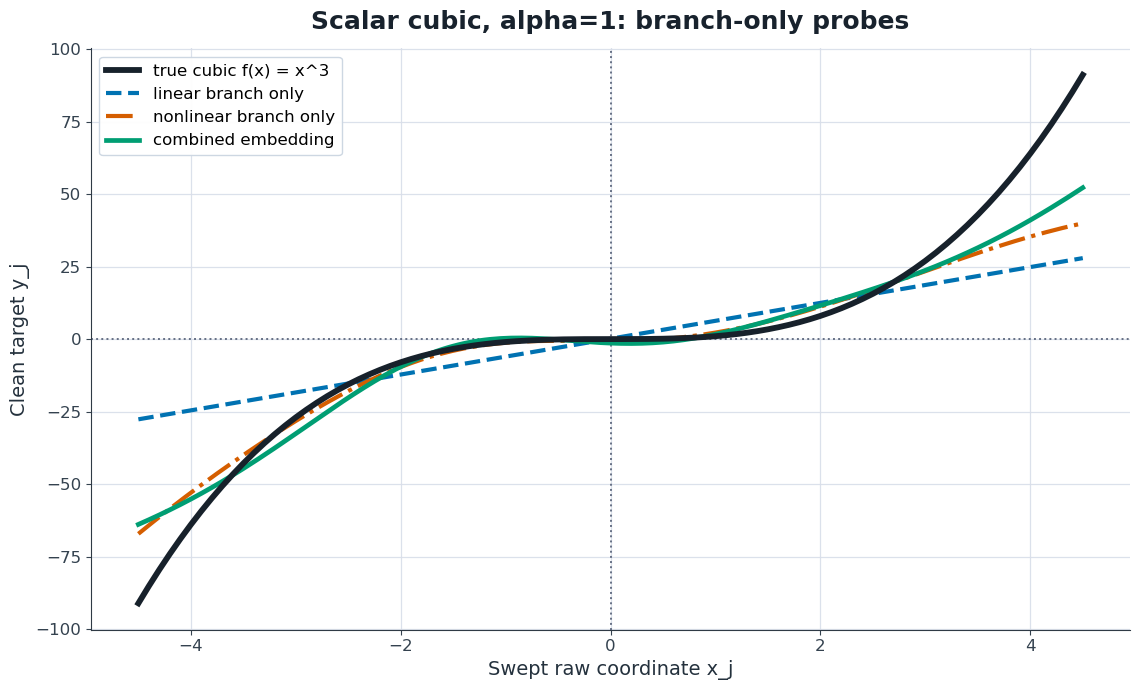

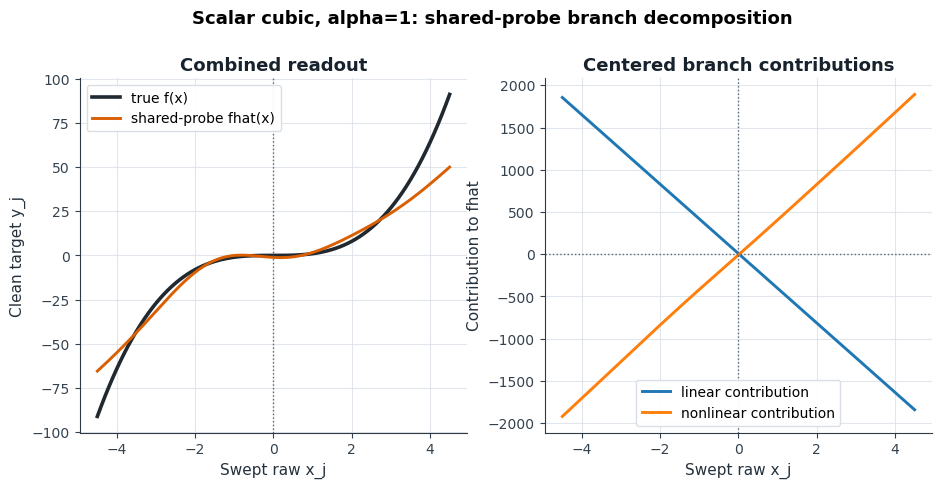

In [29]:
scalar_sweep = np.linspace(-3 * X_STD, 3 * X_STD, 181)

scalar_branch_curves = branch_only_probe_curve(
    run=scalar_run,
    raw_dataset=scalar_dataset,
    relationship=RELATIONSHIP,
    coordinate=0,
    sweep_values=scalar_sweep,
)

plot_branch_only_probe_curve(
    scalar_branch_curves,
    title=f"Scalar {RELATIONSHIP}, alpha=1: branch-only probes",
    filename=f"alpha1-scalar-{RELATIONSHIP}-branch-only-probes.png",
);

scalar_decomposition = shared_probe_decomposition_curve(
    run=scalar_run,
    raw_dataset=scalar_dataset,
    relationship=RELATIONSHIP,
    coordinate=0,
    sweep_values=scalar_sweep,
)

plot_shared_probe_decomposition(
    scalar_decomposition,
    title=f"Scalar {RELATIONSHIP}, alpha=1: shared-probe branch decomposition",
    filename=f"alpha1-scalar-{RELATIONSHIP}-shared-probe-decomposition.png",
);


### Large Reproduction Of The Branch-Only Plot

Run this cell after `scalar_branch_curves` has been created. It does not retrain the model; it only redraws the same branch-only probe curves in a larger, cleaner style.


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-only-probes-large.png


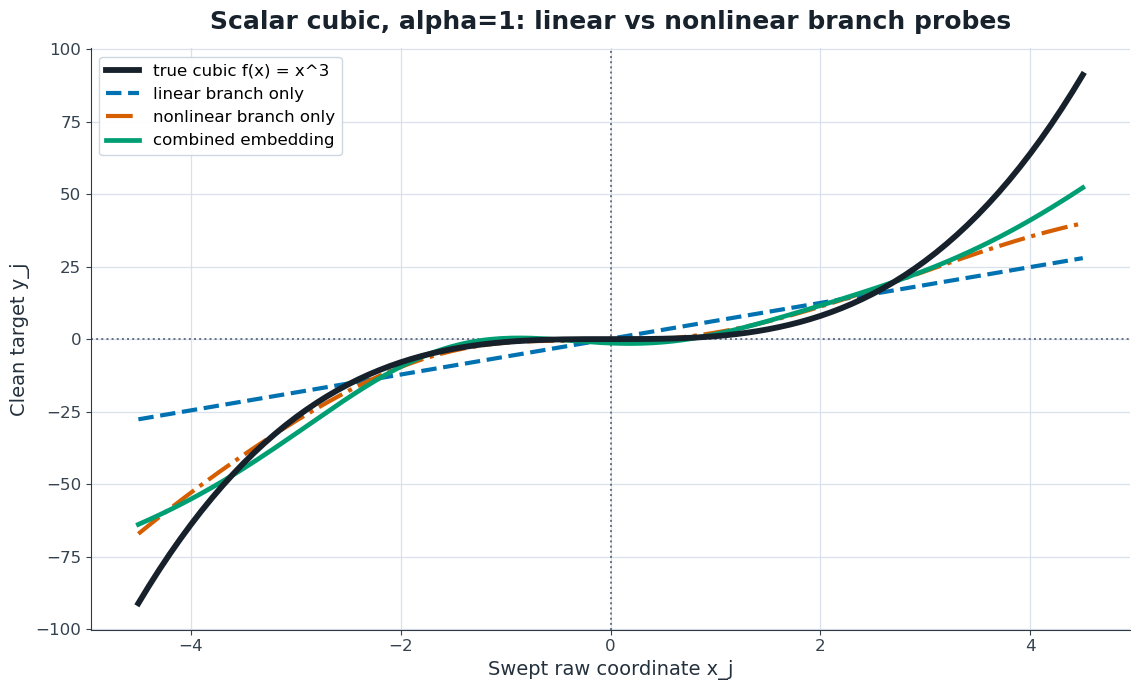

In [30]:
plot_branch_only_probe_curve(
    scalar_branch_curves,
    title=f"Scalar {RELATIONSHIP}, alpha=1: linear vs nonlinear branch probes",
    filename=f"alpha1-scalar-{RELATIONSHIP}-branch-only-probes-large.png",
);


## 4. Scalar Verification Plots

The branch-only plot is suggestive, but these checks make the interpretation more concrete. They quantify how close each curve is to the true cubic, how much linear/cubic polynomial shape each readout contains, and whether the nonlinear branch has actual curvature rather than just a different straight line.


In [31]:
def r2_score_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    total = np.sum((y_true - y_true.mean()) ** 2)
    residual = np.sum((y_true - y_pred) ** 2)
    return float(1.0 - residual / max(total, 1e-12))


def curve_fit_summary(curves: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for readout, subset in curves.groupby("readout", sort=False):
        y_true = subset["true_y"].to_numpy(dtype=float)
        y_pred = subset["predicted_y"].to_numpy(dtype=float)
        error = y_pred - y_true
        rows.append(
            {
                "readout": readout,
                "curve_r2_vs_true": r2_score_np(y_true, y_pred),
                "rmse": float(np.sqrt(np.mean(error**2))),
                "mae": float(np.mean(np.abs(error))),
                "corr_with_true": float(np.corrcoef(y_true, y_pred)[0, 1]),
                "max_abs_error": float(np.max(np.abs(error))),
            }
        )
    return pd.DataFrame(rows)


def polynomial_shape_summary(curves: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for readout, subset in curves.groupby("readout", sort=False):
        x = subset["x_value"].to_numpy(dtype=float)
        y = subset["predicted_y"].to_numpy(dtype=float)
        basis = np.column_stack([x, x**2, x**3])
        basis_mean = basis.mean(axis=0, keepdims=True)
        basis_scale = basis.std(axis=0, keepdims=True)
        basis_scale = np.where(basis_scale > 1e-12, basis_scale, 1.0)
        y_mean = y.mean()
        y_scale = y.std()
        y_scale = y_scale if y_scale > 1e-12 else 1.0

        basis_z = (basis - basis_mean) / basis_scale
        y_z = (y - y_mean) / y_scale
        coefs, *_ = np.linalg.lstsq(basis_z, y_z, rcond=None)
        y_fit_z = basis_z @ coefs

        rows.append(
            {
                "readout": readout,
                "poly_r2_for_readout": r2_score_np(y_z, y_fit_z),
                "standardized_x_coef": float(coefs[0]),
                "standardized_x2_coef": float(coefs[1]),
                "standardized_x3_coef": float(coefs[2]),
                "abs_x3_over_abs_x": float(abs(coefs[2]) / max(abs(coefs[0]), 1e-12)),
            }
        )
    return pd.DataFrame(rows)


curve_summary = curve_fit_summary(scalar_branch_curves)
poly_summary = polynomial_shape_summary(scalar_branch_curves)
verification_summary = curve_summary.merge(poly_summary, on="readout")
display(friendly_results_table(verification_summary.round(4)))


,readout,curve_r2_vs_true,rmse,mae,corr_with_true,max_abs_error,poly_r2_for_readout,standardized_x_coef,standardized_x2_coef,standardized_x3_coef,abs_x3_over_abs_x
0,linear branch only,0.6324,21.2300,13.4029,0.9165,63.4525,1.0000,1.0000,0.0000,0.0000,0.0000
1,nonlinear branch only,0.8809,12.0855,6.2139,0.9715,51.1976,0.9914,0.3998,-0.1481,0.6051,1.5134
2,combined embedding,0.9164,10.1260,5.8518,0.9780,38.9076,0.9885,0.3617,-0.1057,0.6464,1.7871


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-only-residuals.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-branch-slope-curvature.png


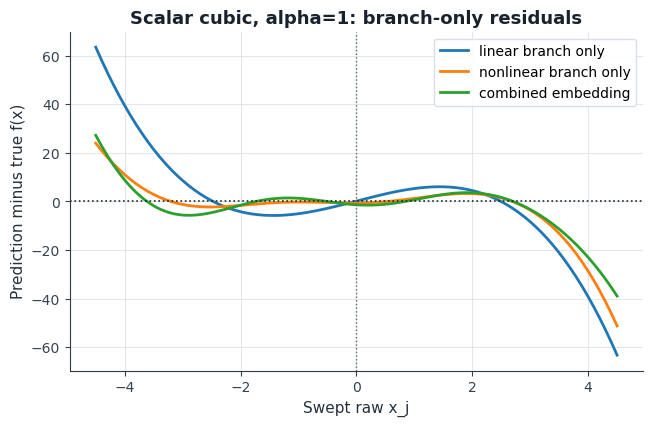

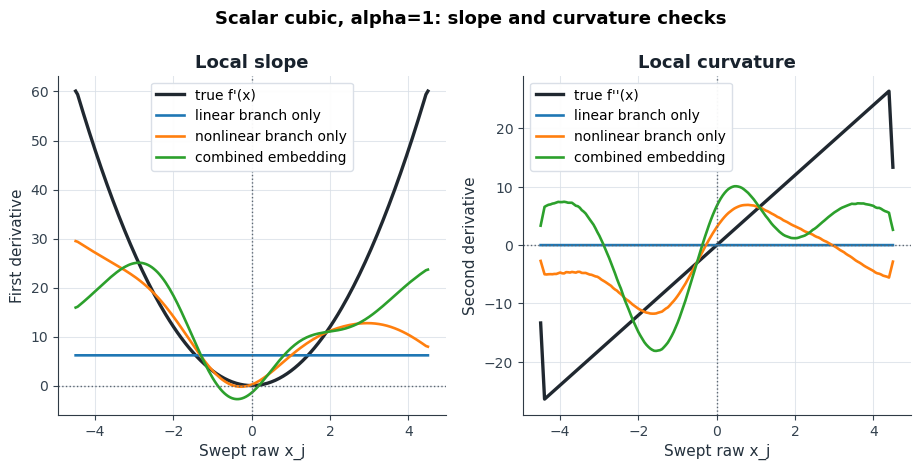

In [32]:
def plot_branch_residuals(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(7.4, 4.4))
    for readout, subset in curves.groupby("readout", sort=False):
        subset = subset.sort_values("x_value")
        ax.plot(
            subset["x_value"],
            subset["predicted_y"] - subset["true_y"],
            linewidth=2.0,
            label=readout,
        )
    ax.axhline(0, linestyle=":", color="#202830", linewidth=1.2)
    ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Swept raw x_j")
    ax.set_ylabel("Prediction minus true f(x)")
    ax.grid(axis="both", alpha=0.75)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


def plot_branch_curvature(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharex=True)
    true_curve = curves[["x_value", "true_y"]].drop_duplicates().sort_values("x_value")
    x_true = true_curve["x_value"].to_numpy(dtype=float)
    y_true = true_curve["true_y"].to_numpy(dtype=float)
    true_slope = np.gradient(y_true, x_true)
    true_curvature = np.gradient(true_slope, x_true)
    axes[0].plot(x_true, true_slope, color="#202830", linewidth=2.4, label="true f'(x)")
    axes[1].plot(x_true, true_curvature, color="#202830", linewidth=2.4, label="true f''(x)")

    for readout, subset in curves.groupby("readout", sort=False):
        subset = subset.sort_values("x_value")
        x = subset["x_value"].to_numpy(dtype=float)
        y = subset["predicted_y"].to_numpy(dtype=float)
        slope = np.gradient(y, x)
        curvature = np.gradient(slope, x)
        axes[0].plot(x, slope, linewidth=1.9, label=readout)
        axes[1].plot(x, curvature, linewidth=1.9, label=readout)

    axes[0].set_title("Local slope")
    axes[0].set_ylabel("First derivative")
    axes[1].set_title("Local curvature")
    axes[1].set_ylabel("Second derivative")
    for ax in axes:
        ax.axhline(0, linestyle=":", color="#5C6670", linewidth=1.0)
        ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
        ax.set_xlabel("Swept raw x_j")
        ax.grid(axis="both", alpha=0.75)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend()

    fig.suptitle(title, y=1.03, fontsize=13, fontweight="semibold")
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


plot_branch_residuals(
    scalar_branch_curves,
    title=f"Scalar {RELATIONSHIP}, alpha=1: branch-only residuals",
    filename=f"alpha1-scalar-{RELATIONSHIP}-branch-only-residuals.png",
);

plot_branch_curvature(
    scalar_branch_curves,
    title=f"Scalar {RELATIONSHIP}, alpha=1: slope and curvature checks",
    filename=f"alpha1-scalar-{RELATIONSHIP}-branch-slope-curvature.png",
);


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-shared-probe-target-scale.png


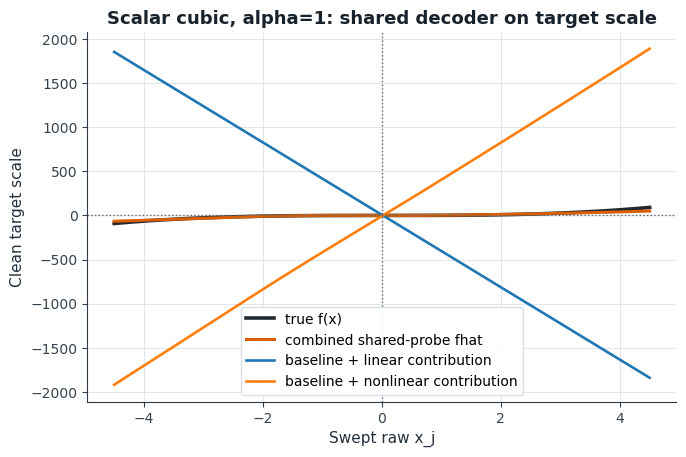

In [33]:
def plot_shared_probe_target_scale(curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    curves = curves.sort_values("x_value").copy()
    baseline = curves["combined_prediction"] - curves["linear_contribution"] - curves["nonlinear_contribution"]
    curves["linear_on_target_scale"] = baseline + curves["linear_contribution"]
    curves["nonlinear_on_target_scale"] = baseline + curves["nonlinear_contribution"]

    fig, ax = plt.subplots(figsize=(7.6, 4.8))
    ax.plot(curves["x_value"], curves["true_y"], color="#202830", linewidth=2.6, label="true f(x)")
    ax.plot(curves["x_value"], curves["combined_prediction"], color="#D95F02", linewidth=2.2, label="combined shared-probe fhat")
    ax.plot(curves["x_value"], curves["linear_on_target_scale"], linewidth=1.9, label="baseline + linear contribution")
    ax.plot(curves["x_value"], curves["nonlinear_on_target_scale"], linewidth=1.9, label="baseline + nonlinear contribution")
    ax.axhline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
    ax.set_title(title)
    ax.set_xlabel("Swept raw x_j")
    ax.set_ylabel("Clean target scale")
    ax.grid(axis="both", alpha=0.75)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend()
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


plot_shared_probe_target_scale(
    scalar_decomposition,
    title=f"Scalar {RELATIONSHIP}, alpha=1: shared decoder on target scale",
    filename=f"alpha1-scalar-{RELATIONSHIP}-shared-probe-target-scale.png",
);


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-scalar-cubic-raw-branch-components.png


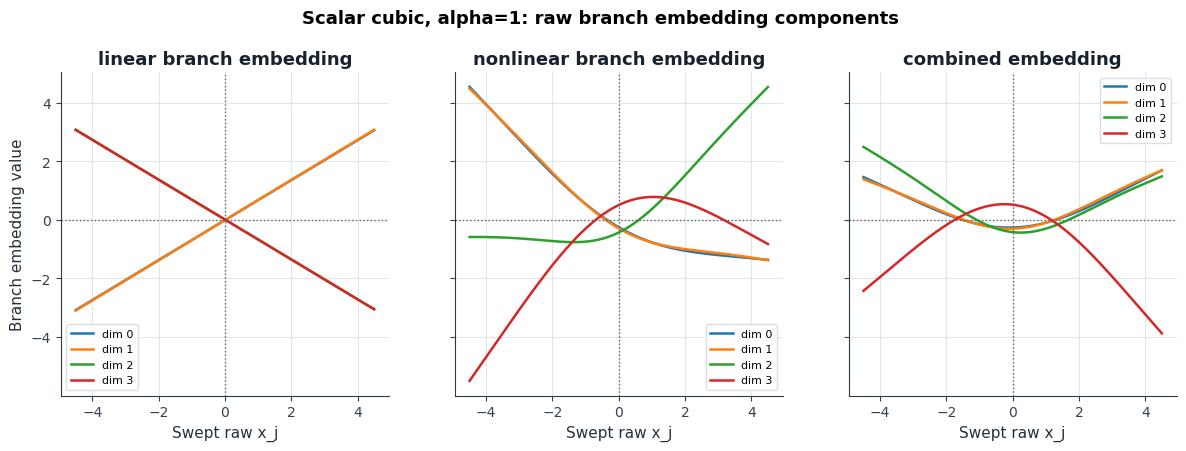

In [34]:
def branch_embedding_component_curves(run, raw_dataset, coordinate: int, sweep_values: np.ndarray, device: str = DEVICE) -> pd.DataFrame:
    X_sweep = make_coordinate_sweep(raw_dataset, coordinate, sweep_values, base_observation=None)
    X_sweep_standardized = standardize_like_training(X_sweep, raw_dataset.X_train)
    linear_sweep, nonlinear_sweep, total_sweep = branch_components_numpy(run.model, X_sweep_standardized, device=device)
    records = []
    for branch_name, values in [
        ("linear branch embedding", linear_sweep),
        ("nonlinear branch embedding", nonlinear_sweep),
        ("combined embedding", total_sweep),
    ]:
        for dim in range(values.shape[1]):
            records.append(
                pd.DataFrame(
                    {
                        "branch": branch_name,
                        "embedding_dim": dim,
                        "x_value": sweep_values,
                        "value": values[:, dim],
                    }
                )
            )
    return pd.concat(records, ignore_index=True)


def plot_branch_embedding_components(component_curves: pd.DataFrame, title: str, filename: str | None = None) -> plt.Figure:
    branches = list(component_curves["branch"].drop_duplicates())
    fig, axes = plt.subplots(1, len(branches), figsize=(4.8 * len(branches), 4.2), sharex=True, sharey=True)
    if len(branches) == 1:
        axes = [axes]
    for ax, branch_name in zip(axes, branches):
        branch_data = component_curves[component_curves["branch"] == branch_name]
        for dim, subset in branch_data.groupby("embedding_dim", sort=True):
            subset = subset.sort_values("x_value")
            ax.plot(subset["x_value"], subset["value"], linewidth=1.8, label=f"dim {dim}")
        ax.axhline(0, linestyle=":", color="#5C6670", linewidth=1.0)
        ax.axvline(0, linestyle=":", color="#5C6670", linewidth=1.0)
        ax.set_title(branch_name)
        ax.set_xlabel("Swept raw x_j")
        ax.grid(axis="both", alpha=0.75)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("Branch embedding value")
    fig.suptitle(title, y=1.03, fontsize=13, fontweight="semibold")
    if filename is not None:
        save_current_figure(fig, filename)
    return fig


scalar_component_curves = branch_embedding_component_curves(
    run=scalar_run,
    raw_dataset=scalar_dataset,
    coordinate=0,
    sweep_values=scalar_sweep,
)

plot_branch_embedding_components(
    scalar_component_curves,
    title=f"Scalar {RELATIONSHIP}, alpha=1: raw branch embedding components",
    filename=f"alpha1-scalar-{RELATIONSHIP}-raw-branch-components.png",
);


## 5. Optional 128-D Coordinate Check

This repeats the same alpha=1 branch plots for one coordinate of a `p=q=128` deterministic dataset. This is harder to interpret than the scalar check because a 4-dimensional embedding is a severe bottleneck for 128 independent coordinatewise targets.


In [35]:
RUN_128D_CHECK = True

if RUN_128D_CHECK:
    dataset_128 = generate_deterministic_relation_dataset(
        n_train=256,
        n_test=512,
        p=128,
        q=128,
        relationship=RELATIONSHIP,
        target_snr=TARGET_SNR,
        rng=np.random.default_rng(GLOBAL_SEED + 7200),
        x_std=X_STD,
    )

    run_128 = train_one_model_with_artifacts(
        dataset=dataset_128,
        config=alpha1_config,
        seed=GLOBAL_SEED + 7300,
        device=DEVICE,
    )

    display(
        friendly_results_table(
            pd.DataFrame(
                [
                    {
                        "config": alpha1_config.name,
                        "p": 128,
                        "q": 128,
                        "final_loss": run_128.metrics["final_loss"],
                        "test_pair_separation": run_128.metrics["test_pair_separation"],
                        "test_top5_pair_match_accuracy": run_128.metrics["test_top5_pair_match_accuracy"],
                        "x_probe_r2_z_y": run_128.metrics["x_probe_r2_z_y"],
                        "mean_nonlinear_to_linear_ratio": run_128.metrics["mean_nonlinear_to_linear_ratio"],
                    }
                ]
            ).round(4)
        )
    )


,Model,p,q,final_loss,Test true-pair separation,Test top-5 retrieval accuracy,X probe R^2 for Z_y,Mean nonlinear/linear ratio
0,MLP nonlinear alpha=1.00,128,128,9.9977,0.3234,0.0176,-0.0237,0.978


saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-128d-cubic-coordinate-0-branch-only-probes.png
saved /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/alpha1-128d-cubic-coordinate-0-shared-probe-decomposition.png


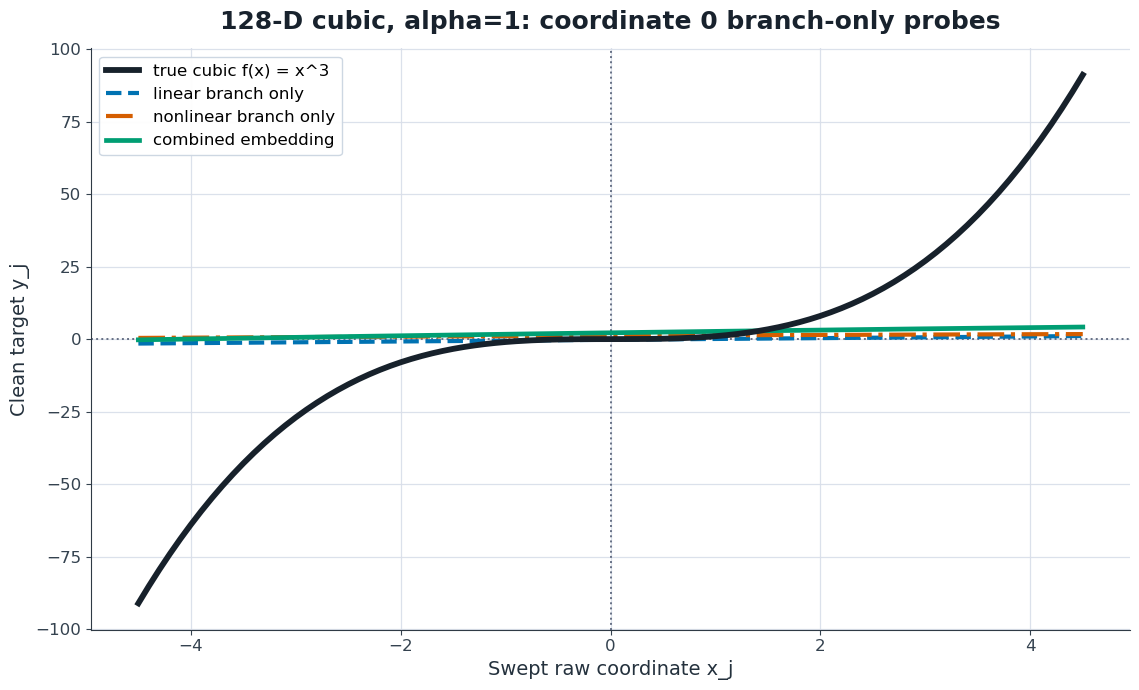

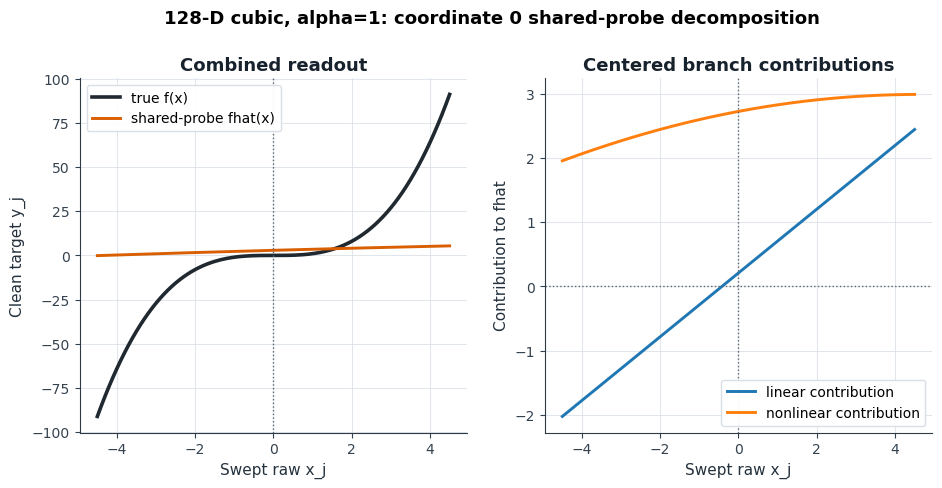

In [36]:
if RUN_128D_CHECK:
    COORDINATE_128 = 0
    sweep_128 = np.linspace(-3 * X_STD, 3 * X_STD, 181)

    curves_128 = branch_only_probe_curve(
        run=run_128,
        raw_dataset=dataset_128,
        relationship=RELATIONSHIP,
        coordinate=COORDINATE_128,
        sweep_values=sweep_128,
    )

    plot_branch_only_probe_curve(
        curves_128,
        title=f"128-D {RELATIONSHIP}, alpha=1: coordinate {COORDINATE_128} branch-only probes",
        filename=f"alpha1-128d-{RELATIONSHIP}-coordinate-{COORDINATE_128}-branch-only-probes.png",
    );

    decomposition_128 = shared_probe_decomposition_curve(
        run=run_128,
        raw_dataset=dataset_128,
        relationship=RELATIONSHIP,
        coordinate=COORDINATE_128,
        sweep_values=sweep_128,
    )

    plot_shared_probe_decomposition(
        decomposition_128,
        title=f"128-D {RELATIONSHIP}, alpha=1: coordinate {COORDINATE_128} shared-probe decomposition",
        filename=f"alpha1-128d-{RELATIONSHIP}-coordinate-{COORDINATE_128}-shared-probe-decomposition.png",
    );


## 6. Reading The Result

- If the branch-only nonlinear curve tracks `f(x)` better than the branch-only linear curve, the nonlinear branch alone contains the curved relation.
- If the shared-probe nonlinear contribution has the curved shape while the linear contribution is mostly straight or flat, the nonlinear correction is carrying the curvature in the combined model.
- If the combined curve is good but both branch-only curves are odd, trust the shared-probe decomposition more. The branch-only probes use different decoders, so they answer a different question.
- If the 128-D coordinate plot is weak while the scalar plot is strong, that points toward the low-dimensional embedding bottleneck rather than a failure to learn a scalar nonlinear function.
